#**CHURN PREDICTION**

##IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import recall_score, accuracy_score, classification_report, confusion_matrix, precision_recall_curve,f1_score,precision_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from time import time
import warnings
warnings.filterwarnings('ignore')

##DATA LOADING

In [2]:
df1= pd.read_csv("/content/churn-bigml-80.csv")
df1.head(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
df2= pd.read_csv("/content/churn-bigml-20.csv")
df2.head(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [4]:
print(df1.shape)
print(df2.shape)

(2666, 20)
(667, 20)


In [5]:
df=pd.concat([df1,df2],axis=0)
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [6]:
df.shape

(3333, 20)

##DATA EXPLORATION & CLEANING

In [7]:
df.shape

(3333, 20)

In [8]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3333 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   float6

In [10]:
df['State'].value_counts()

,count
State,
WV,106
MN,84
NY,83
AL,80
OR,78
WI,78
OH,78
VA,77
WY,77


In [11]:
df['International plan'].value_counts()

,count
International plan,
No,3010
Yes,323


In [12]:
df['Voice mail plan'].value_counts()

,count
Voice mail plan,
No,2411
Yes,922


In [13]:
pd.DataFrame({
    'Count': df['Churn'].value_counts(),
    'Percentage': df['Churn'].value_counts()/np.sum(df['Churn'].value_counts()/100)
})


,Count,Percentage
Churn,,
False,2850,85.508551
True,483,14.491449


In [14]:
df.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


In [15]:
categorical_columns=['State','International plan','Voice mail plan']

numerical_columns=df.drop(columns=categorical_columns,axis=1)
numerical_columns.head()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


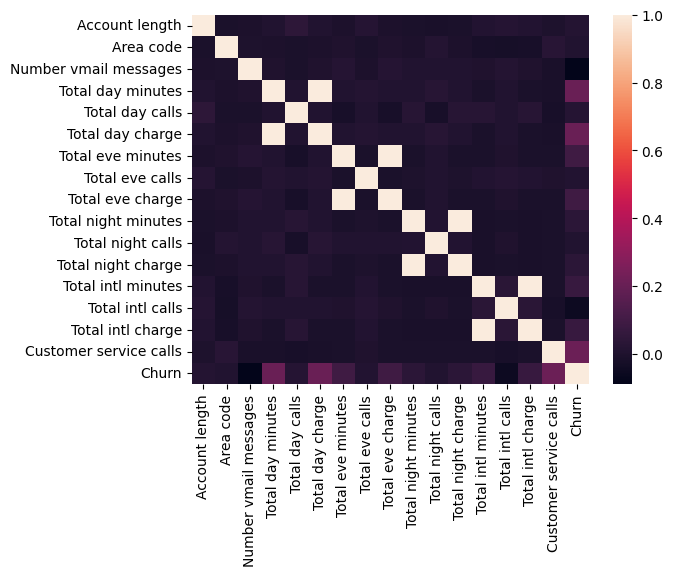

In [16]:
sns.heatmap(numerical_columns.corr())
plt.show()

In [17]:
# Make a copy to avoid modifying the original df
df_vif = df.copy()

# Convert binary categorical features to numerical
df_vif['International plan'] = df_vif['International plan'].map({'Yes': 1, 'No': 0})
df_vif['Voice mail plan'] = df_vif['Voice mail plan'].map({'Yes': 1, 'No': 0})

# One-hot encode 'Area code' (since it's categorical despite being int64)
df_vif = pd.get_dummies(df_vif, columns=['Area code'], drop_first=True)

# Drop the target variable 'Churn' and high cardinality 'State'
X = df_vif.drop(columns=['Churn', 'State'])

# Ensure all columns in X are numeric before VIF calculation
X_numeric = X.select_dtypes(include=[np.number])

# Drop any columns that might have constant values (zero variance) as VIF cannot be computed for them
X_numeric = X_numeric.loc[:, (X_numeric != X_numeric.iloc[0]).any()]

# Check if X_numeric is empty after dropping constant columns
if X_numeric.empty:
    print("No suitable numeric features found for VIF calculation after transformations and constant value check.")
else:
    # Add a constant to the DataFrame (required for VIF calculation)
    X_const = add_constant(X_numeric)

    # Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

    # Sort by VIF in descending order for better readability
    vif_data = vif_data.sort_values(by="VIF", ascending=False)

    print("Variance Inflation Factor (VIF) for features:")
    print(vif_data)


Variance Inflation Factor (VIF) for features:
                   feature           VIF
7         Total day charge  1.047617e+07
5        Total day minutes  1.047616e+07
10        Total eve charge  2.237335e+06
8        Total eve minutes  2.237334e+06
11     Total night minutes  6.387661e+05
13      Total night charge  6.387648e+05
14      Total intl minutes  6.907441e+04
16       Total intl charge  6.907440e+04
0                    const  1.429712e+02
3          Voice mail plan  1.190453e+01
4    Number vmail messages  1.190351e+01
2       International plan  1.008221e+00
6          Total day calls  1.004704e+00
1           Account length  1.004366e+00
15        Total intl calls  1.003815e+00
12       Total night calls  1.003217e+00
17  Customer service calls  1.002660e+00
9          Total eve calls  1.002310e+00


In [18]:
drop_columns=['State','Total eve charge','Total day charge','Total night charge','Total intl charge']

In [19]:
df.drop(columns=drop_columns,inplace=True)
df.head()

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,128,415,No,Yes,25,265.1,110,197.4,99,244.7,91,10.0,3,1,False
1,107,415,No,Yes,26,161.6,123,195.5,103,254.4,103,13.7,3,1,False
2,137,415,No,No,0,243.4,114,121.2,110,162.6,104,12.2,5,0,False
3,84,408,Yes,No,0,299.4,71,61.9,88,196.9,89,6.6,7,2,False
4,75,415,Yes,No,0,166.7,113,148.3,122,186.9,121,10.1,3,3,False


In [20]:
categorical_columns=['International plan','Voice mail plan']

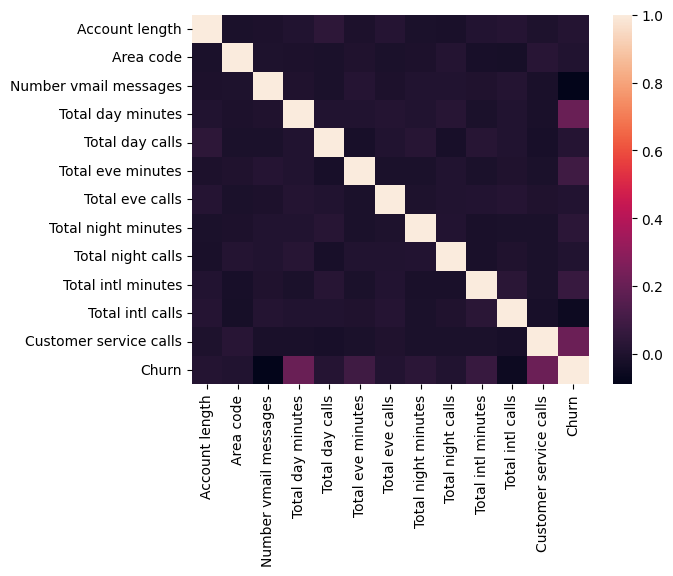

In [21]:
sns.heatmap(df.drop(columns=categorical_columns).corr())
plt.show()

##DATA ENCODING

In [22]:
df.head()

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,128,415,No,Yes,25,265.1,110,197.4,99,244.7,91,10.0,3,1,False
1,107,415,No,Yes,26,161.6,123,195.5,103,254.4,103,13.7,3,1,False
2,137,415,No,No,0,243.4,114,121.2,110,162.6,104,12.2,5,0,False
3,84,408,Yes,No,0,299.4,71,61.9,88,196.9,89,6.6,7,2,False
4,75,415,Yes,No,0,166.7,113,148.3,122,186.9,121,10.1,3,3,False


In [23]:
df['International plan']=df['International plan'].map({'Yes':1,'No':0})
df['Voice mail plan']=df['Voice mail plan'].map({'Yes':1,'No':0})
df['Churn']=df['Churn'].map({True:1,False:0})
df.head()

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,128,415,0,1,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0
1,107,415,0,1,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0
2,137,415,0,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0
3,84,408,1,0,0,299.4,71,61.9,88,196.9,89,6.6,7,2,0
4,75,415,1,0,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0


##DATA SPLITTING

In [24]:
X=df.drop(columns='Churn')
Y=df['Churn']

In [25]:
X_Train,X_Test,Y_Train,Y_Test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [26]:
print(X_Train.shape)
print(X_Test.shape)
print(Y_Train.shape)
print(Y_Test.shape)

(2666, 14)
(667, 14)
(2666,)
(667,)


In [27]:
Y_Train.value_counts()

,count
Churn,
0,2280
1,386


In [28]:
Y_Test.value_counts()

,count
Churn,
0,570
1,97


##MODEL BUILDING

##RANDOM FOREST - BASELINE


In [29]:
rf=RandomForestClassifier(n_estimators=300,random_state=42,criterion='gini',max_features='sqrt',oob_score=True)
rf.fit(X_Train,Y_Train)

RandomForestClassifier(n_estimators=300, oob_score=True, random_state=42)

In [30]:
rf_train_pred=rf.predict(X_Train)
rf_test_pred=rf.predict(X_Test)


In [31]:
rf_recall=recall_score(Y_Test,rf_test_pred)
rf_recall

0.6288659793814433

In [32]:
rf_pr_auc=precision_recall_curve(Y_Test,rf_test_pred)
rf_pr_auc

(array([0.14542729, 0.96825397, 1.        ]),
 array([1.        , 0.62886598, 0.        ]),
 array([0, 1]))

In [33]:
rf_classication_report=classification_report(Y_Test,rf_test_pred)
print(rf_classication_report)

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       570
           1       0.97      0.63      0.76        97

    accuracy                           0.94       667
   macro avg       0.95      0.81      0.87       667
weighted avg       0.94      0.94      0.94       667



In [34]:
rf.feature_importances_

array([0.05028983, 0.01394651, 0.08485142, 0.01957153, 0.02780226,
       0.25814258, 0.0522382 , 0.09517727, 0.04521412, 0.06203159,
       0.04846939, 0.07742555, 0.0629596 , 0.10188016])

In [35]:
rf.oob_score_

0.9489872468117029

##XGBOOST- BASELINE

In [36]:
scale_value_train=len(Y_Train[Y_Train==0])/len(Y_Train[Y_Train==1])
scale_value_train

5.9067357512953365

In [37]:
scale_value_test=len(Y_Test[Y_Test==0])/len(Y_Test[Y_Test==1])
scale_value_test

5.876288659793815

In [38]:
XGB=xgb.XGBClassifier(random_state=42,scale_pos_weight=5.8)
XGB.fit(X_Train,Y_Train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [39]:
XGB_train_pred=XGB.predict(X_Train)
XGB_test_pred=XGB.predict(X_Test)

In [40]:
XGB_recall=recall_score(Y_Test,XGB_test_pred)
XGB_recall

0.7628865979381443

In [41]:
XGB_pr_auc=precision_recall_curve(Y_Test,XGB_test_pred)
XGB_pr_auc

(array([0.14542729, 0.925     , 1.        ]),
 array([1.       , 0.7628866, 0.       ]),
 array([0, 1]))

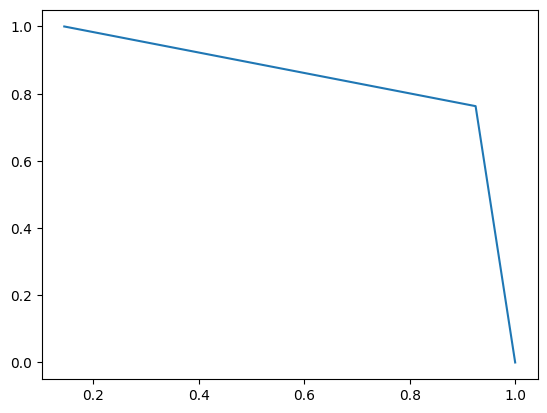

In [42]:
plt.plot(XGB_pr_auc[0],XGB_pr_auc[1])
plt.show()

In [43]:
XGB_classification_report=classification_report(Y_Test,XGB_test_pred)
print(XGB_classification_report)

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       570
           1       0.93      0.76      0.84        97

    accuracy                           0.96       667
   macro avg       0.94      0.88      0.91       667
weighted avg       0.96      0.96      0.95       667



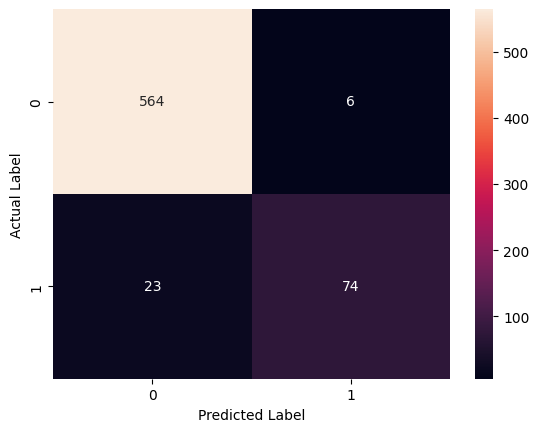

In [44]:
sns.heatmap(confusion_matrix(Y_Test,XGB_test_pred),annot=True,fmt='d')
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

##XGBOOST - HYPERPARAMETER TUNING

In [45]:
param_grid=({
        'n_estimators':[100,200,300,400],
        'max_depth':[4,5,6,7],
        'learning_rate': [0.001,0.01,0.1,1],
        'subsample':[0.5,0.7,1],
        'colsample_bytree':[0.5,0.7,1],
        'gamma':[0,0.1,0.2,0.3],
        'reg_lambda':[0,0.1,0.2],
        'reg_alpha':[0,0.1,0.2],
        'min_child_weight':[1,2,3,4,5],
        'scale_pos_weight': [3, 5, 6]
   })

In [46]:
Xgb_model=xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

In [47]:
random_search=RandomizedSearchCV(
    estimator=Xgb_model,
    param_distributions=param_grid,
    n_iter=100,
    scoring='recall',
    cv=5,
    verbose=2,
    n_jobs=-1
    )

In [48]:
random_search.fit(X_Train,Y_Train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           num_parallel_tree=None, ...),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.5, 0.7, 1],
                                        'gamma': [0, 0.1, 0.2, 0.3],
                                        'learning_rate': [0.001, 0.01, 0.1, 1],
                                        'max_depth': [4, 5, 6, 7],
                                        'min_child_weight': [1, 2, 3, 4, 5],
                                        'n_estimators': [100, 200, 300, 400],
                                        'reg_alpha': [0, 0.1, 0.2],
                                        'reg_lambda': [0, 0.1, 0.2],
                                        'scale_pos_weight': [3, 5, 6],
                                        'subsample': [0.5, 0.7, 1]},
                   scoring='recall', verbose=2)

In [49]:
random_search.best_params_

{'subsample': 0.5,
 'scale_pos_weight': 6,
 'reg_lambda': 0.2,
 'reg_alpha': 0.1,
 'n_estimators': 100,
 'min_child_weight': 2,
 'max_depth': 4,
 'learning_rate': 0.01,
 'gamma': 0.2,
 'colsample_bytree': 0.7}

In [50]:
random_search.best_score_

np.float64(0.8187812187812188)

In [51]:
best_parameters=random_search.best_params_
print(best_parameters)

{'subsample': 0.5, 'scale_pos_weight': 6, 'reg_lambda': 0.2, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 2, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.7}


In [52]:
best_parameters.update({
    "random_state":42,
    "use_label_encoder":False,
    "eval_metric":'logloss'
})

In [53]:
best_parameters

{'subsample': 0.5,
 'scale_pos_weight': 6,
 'reg_lambda': 0.2,
 'reg_alpha': 0.1,
 'n_estimators': 100,
 'min_child_weight': 2,
 'max_depth': 4,
 'learning_rate': 0.01,
 'gamma': 0.2,
 'colsample_bytree': 0.7,
 'random_state': 42,
 'use_label_encoder': False,
 'eval_metric': 'logloss'}

In [54]:
start_time=time()
print("Training Started at:",start_time)
final_XGB=xgb.XGBClassifier(**best_parameters)
final_XGB.fit(X_Train,Y_Train)
train_time=time()-start_time
print("Training completed at:",train_time)

Training Started at: 1774463782.1238697
Training completed at: 0.10133838653564453


In [55]:
final_XGB_train_pred=final_XGB.predict(X_Train)
final_XGB_test_pred=final_XGB.predict(X_Test)

In [56]:
final_XGB_recall=recall_score(Y_Test,final_XGB_test_pred)
final_XGB_recall

0.8247422680412371

In [57]:
final_XGB_accuracy=accuracy_score(Y_Test,final_XGB_test_pred)
final_XGB_accuracy

0.9280359820089955

(array([0.14542729, 0.72072072, 1.        ]), array([1.        , 0.82474227, 0.        ]), array([0, 1]))


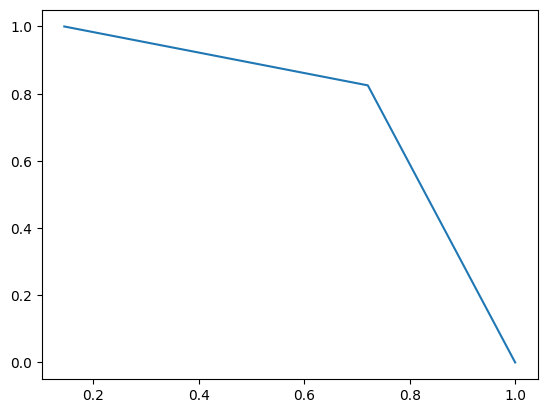

In [58]:
final_XGB_pr_auc=precision_recall_curve(Y_Test,final_XGB_test_pred)
print(final_XGB_pr_auc)
plt.plot(final_XGB_pr_auc[0],final_XGB_pr_auc[1])
plt.show()

In [59]:
final_XGB_f1_score=f1_score(Y_Test,final_XGB_test_pred)
final_XGB_f1_score

0.7692307692307693

In [60]:
final_XGB_classification_report=classification_report(Y_Test,final_XGB_test_pred)
print(final_XGB_classification_report)

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       570
           1       0.72      0.82      0.77        97

    accuracy                           0.93       667
   macro avg       0.85      0.89      0.86       667
weighted avg       0.93      0.93      0.93       667



In [61]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Get predicted probabilities (NOT labels)
y_probs = final_XGB.predict_proba(X_Test)[:, 1]

# Define thresholds
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)

    precision = precision_score(Y_Test, y_pred)
    recall = recall_score(Y_Test, y_pred)
    f1 = f1_score(Y_Test, y_pred)

    tn, fp, fn, tp = confusion_matrix(Y_Test, y_pred).ravel()

    results.append({
        'threshold': t,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'false_positives': fp,
        'false_negatives': fn
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

print(results_df)

    threshold  precision    recall  f1_score  false_positives  false_negatives
0        0.10   0.145427  1.000000  0.253927              570                0
1        0.15   0.145427  1.000000  0.253927              570                0
2        0.20   0.145427  1.000000  0.253927              570                0
3        0.25   0.145646  1.000000  0.254260              569                0
4        0.30   0.157895  0.989691  0.272340              512                1
5        0.35   0.260623  0.948454  0.408889              261                5
6        0.40   0.427184  0.907216  0.580858              118                9
7        0.45   0.555556  0.876289  0.680000               68               12
8        0.50   0.720721  0.824742  0.769231               31               17
9        0.55   0.804348  0.762887  0.783069               18               23
10       0.60   0.871795  0.701031  0.777143               10               29
11       0.65   0.957447  0.463918  0.625000        

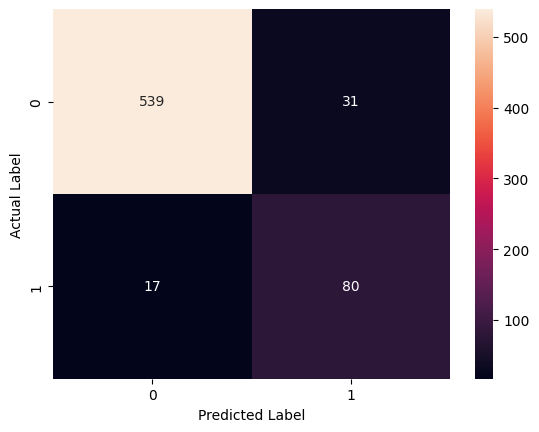

In [62]:
sns.heatmap(confusion_matrix(Y_Test,final_XGB_test_pred),annot=True,fmt='d')
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

In [63]:
import pickle

pickle.dump(final_XGB,open('XGBoost_model.pkl','wb'))
